Ride Booking Data Analysis using Python

Project Objective:-

# 🎯 Project Objective

The objective of this project is to analyze ride booking data to understand booking trends, customer behavior, cancellations, ride performance, and revenue. The analysis aims to generate business insights that can help improve operational efficiency and customer satisfaction.

Import Libraries:-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load Dataset:-

In [2]:
df = pd.read_csv("rideBookings.csv")

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


Data Understanding:-

In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (150000, 21)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [5]:
df.describe

<bound method NDFrame.describe of               Date      Time    Booking ID   Booking Status   Customer ID  \
0       2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1       2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2       2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3       2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4       2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   
...            ...       ...           ...              ...           ...   
149995  2024-11-11  19:34:01  "CNR6500631"        Completed  "CID4337371"   
149996  2024-11-24  15:55:09  "CNR2468611"        Completed  "CID2325623"   
149997  2024-09-18  10:55:15  "CNR6358306"        Completed  "CID9925486"   
149998  2024-10-05  07:53:34  "CNR3030099"        Completed  "CID9415487"   
149999  2024-03-10  15:38:03  "CNR3447390"        Completed  "CID4108667"   

         Vehicle Type         Pickup Loca

In [6]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')

Data Cleaning:-

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df["Time"] = pd.to_datetime(df["Time"]).dt.time

C:\Users\shris\AppData\Local\Temp\ipykernel_2812\3518047455.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"]).dt.time


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["Cancelled Rides by Customer"] = df["Cancelled Rides by Customer"].fillna(0)

df["Cancelled Rides by Driver"] = df["Cancelled Rides by Driver"].fillna(0)

df["Incomplete Rides"] = df["Incomplete Rides"].fillna(0)

In [13]:
df["Reason for cancelling by Customer"] = df["Reason for cancelling by Customer"].fillna("Not Cancelled")

df["Driver Cancellation Reason"] = df["Driver Cancellation Reason"].fillna("Not Cancelled")

df["Incomplete Rides Reason"] = df["Incomplete Rides Reason"].fillna("Completed Ride")

In [14]:
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[us]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  str           
 3   Booking Status                     150000 non-null  str           
 4   Customer ID                        150000 non-null  str           
 5   Vehicle Type                       150000 non-null  str           
 6   Pickup Location                    150000 non-null  str           
 7   Drop Location                      150000 non-null  str           
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer    

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

Q1. What is the distribution of booking status?

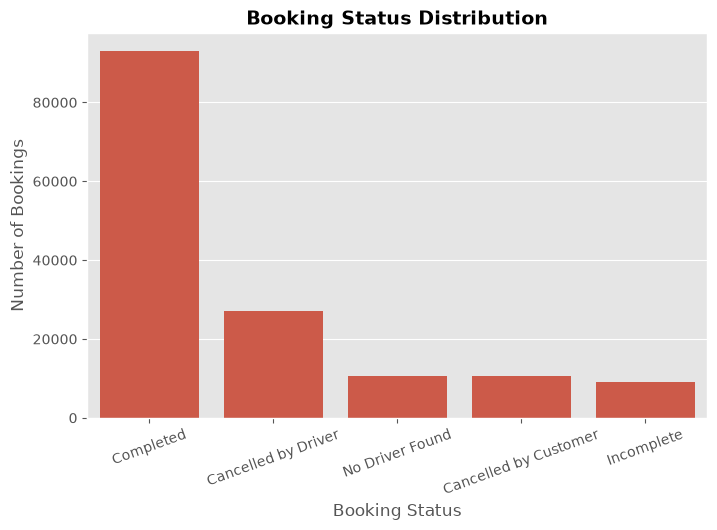

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Booking Status",
    order=df["Booking Status"].value_counts().index
)

plt.title("Booking Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.show()

 Business Insight

Most bookings are successfully completed, while cancelled and incomplete rides represent operational challenges that require attention.

Q2. How do bookings trend over time?

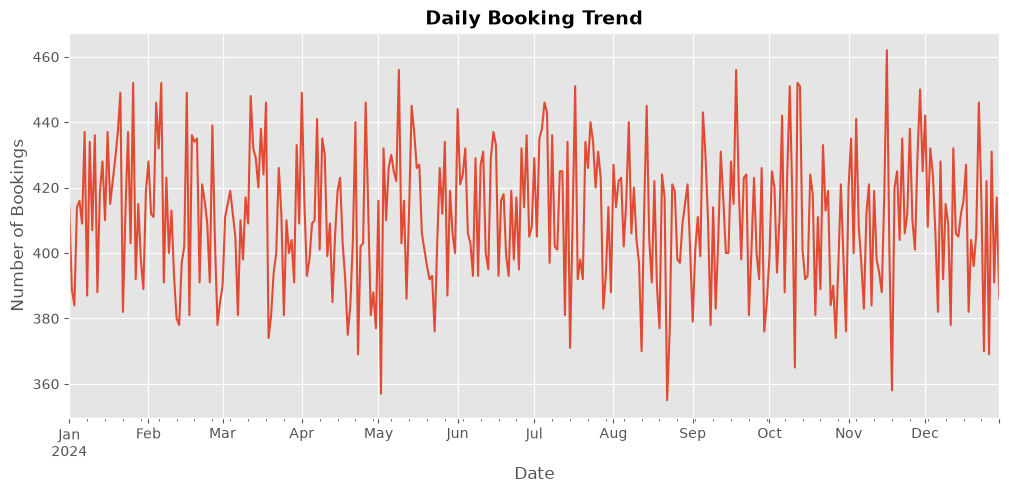

In [18]:
booking_trend = df.groupby("Date").size()

plt.figure(figsize=(12,5))

booking_trend.plot()

plt.title("Daily Booking Trend", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")

plt.show()

Business Insight

Booking demand fluctuates over time, indicating variations in customer demand across different dates.

Q3. What are the peak booking hours?

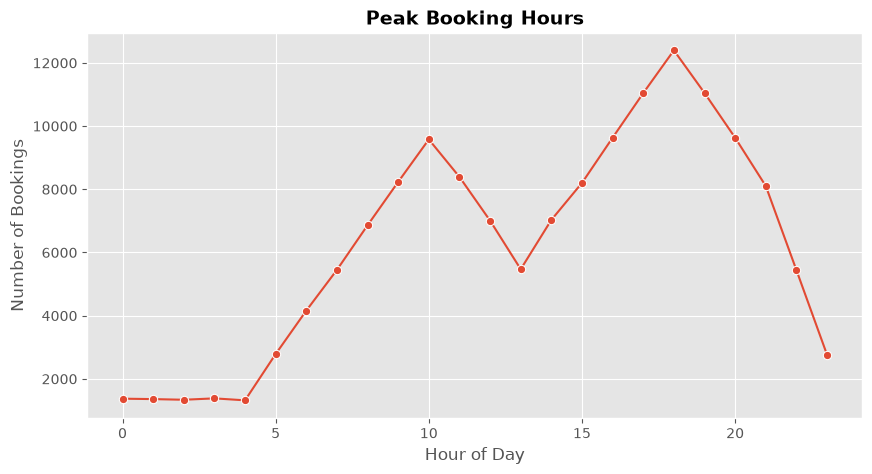

In [19]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

hourly = df.groupby("Hour").size()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o"
)

plt.title("Peak Booking Hours", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")

plt.show()

Business Insight

Peak booking hours indicate the periods with the highest customer demand for rides.

Q4. Which day of the week has the highest ride demand?

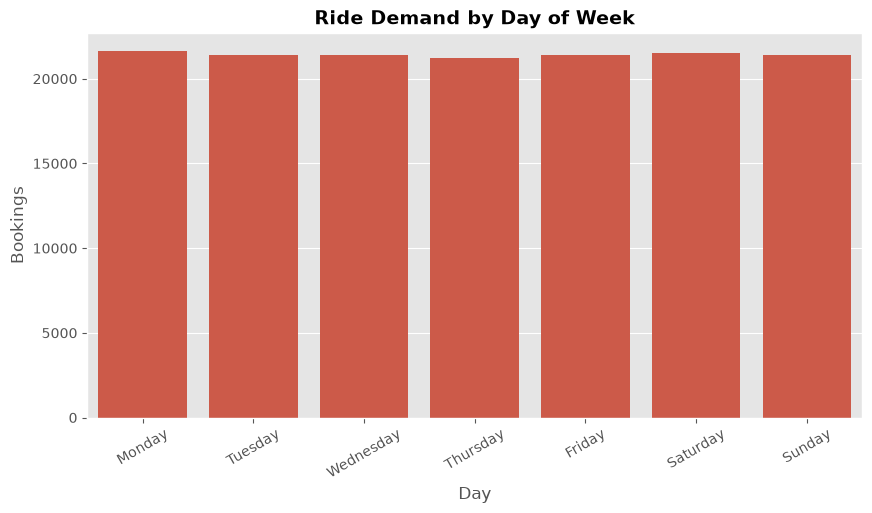

In [20]:
df["Day"] = df["Date"].dt.day_name()

order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Day",
    order=order
)

plt.title("Ride Demand by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Bookings")

plt.xticks(rotation=30)

plt.show()

Business Insight

Ride demand varies across weekdays, helping identify the busiest business days.

Q5. Which vehicle type is most preferred by customers?

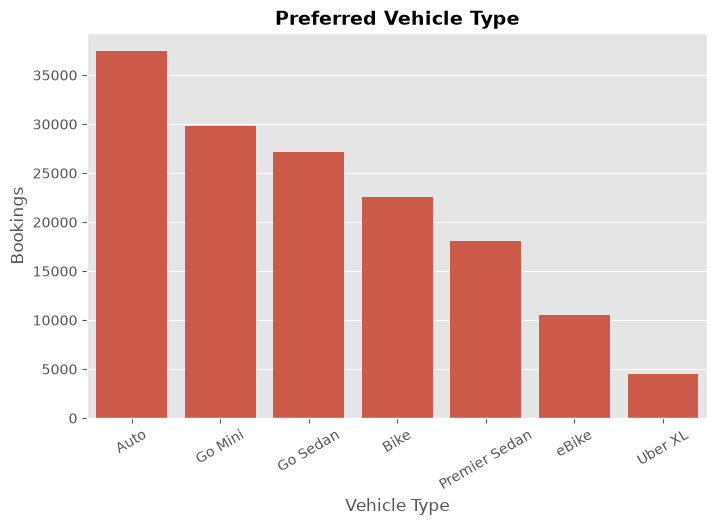

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Vehicle Type",
    order=df["Vehicle Type"].value_counts().index
)

plt.title("Preferred Vehicle Type", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Type")
plt.ylabel("Bookings")

plt.xticks(rotation=30)

plt.show()

Business Insight

The most-booked vehicle category reflects customer preferences and market demand.

Q6. Which vehicle type generates the highest revenue?

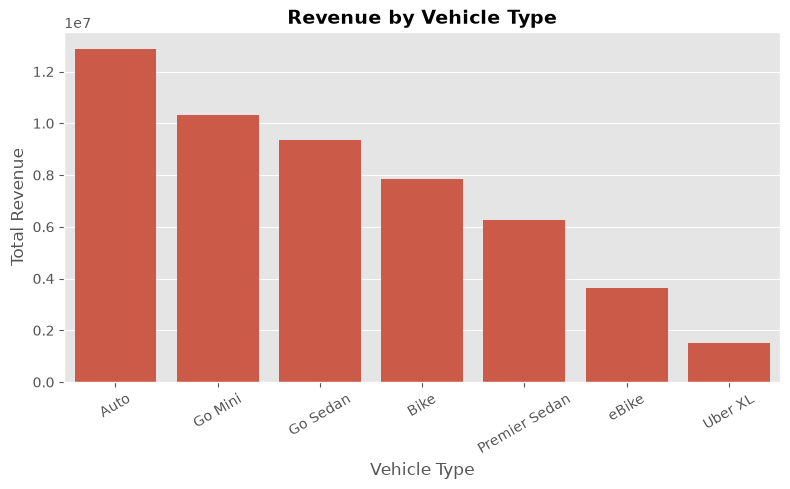

In [22]:
revenue = df.groupby("Vehicle Type")["Booking Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue.index,
    y=revenue.values
)

plt.title("Revenue by Vehicle Type", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Business Insight

Vehicle types generating higher revenue contribute significantly to overall business profitability.

Q7. What is the average booking value?

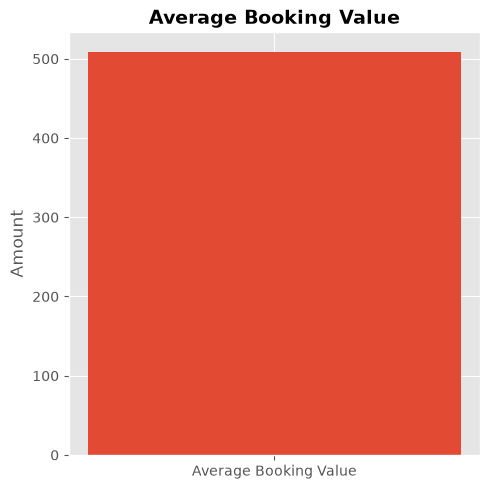

Average Booking Value: 508.3


In [23]:
avg_booking = df["Booking Value"].mean()

plt.figure(figsize=(5,5))

plt.bar(
    ["Average Booking Value"],
    [avg_booking]
)

plt.title("Average Booking Value", fontsize=14, fontweight="bold")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()

print("Average Booking Value:", round(avg_booking,2))

Business Insight

The average booking value reflects customers' typical spending per ride.

Q8. How is the booking value distributed?

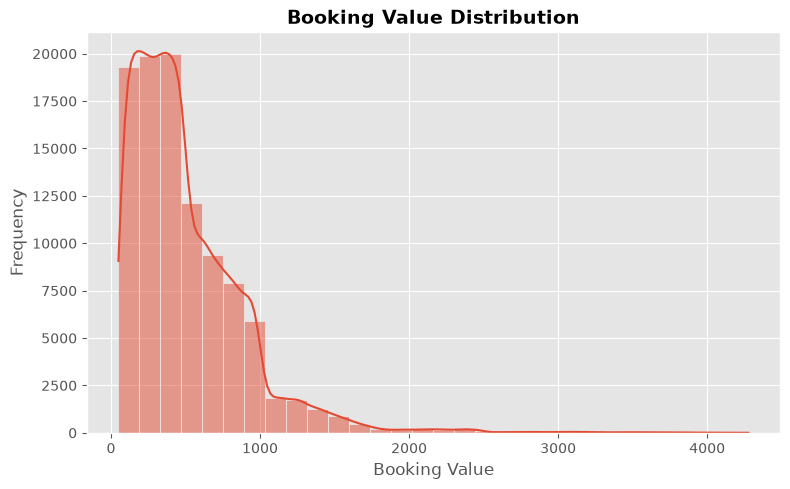

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Booking Value"],
    bins=30,
    kde=True
)

plt.title("Booking Value Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Business Insight

Most bookings fall within a common price range, while high-value bookings occur less frequently.

Q9. What is the distribution of ride distance?

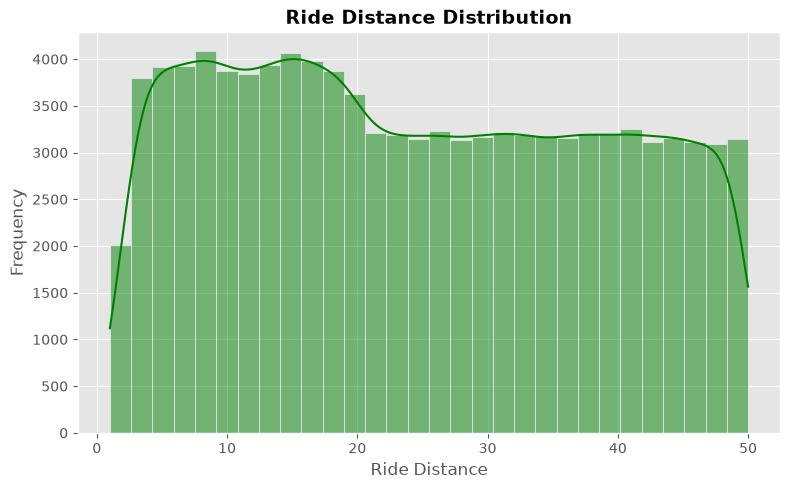

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Ride Distance"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Ride Distance Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Ride Distance")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Business Insight

The majority of rides are short to medium distance, indicating typical urban travel behavior.

Q10. How are customer ratings distributed?

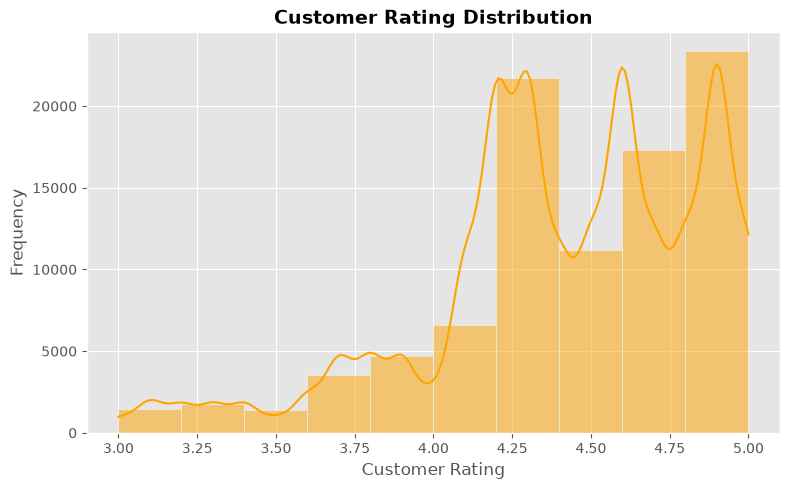

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Customer Rating"],
    bins=10,
    kde=True,
    color="orange"
)

plt.title("Customer Rating Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Business Insight

Most customers provide positive ratings, reflecting overall satisfaction with the service.

Q11. How are driver ratings distributed?

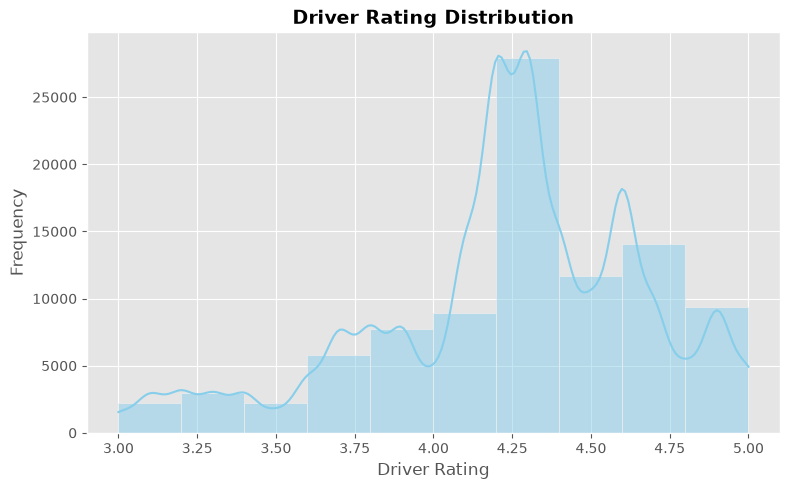

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Driver Ratings"],
    bins=10,
    kde=True,
    color="skyblue"
)

plt.title("Driver Rating Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Business Insight

Most drivers receive good ratings, indicating consistent service quality.

Q12. Is there a relationship between customer and driver ratings?

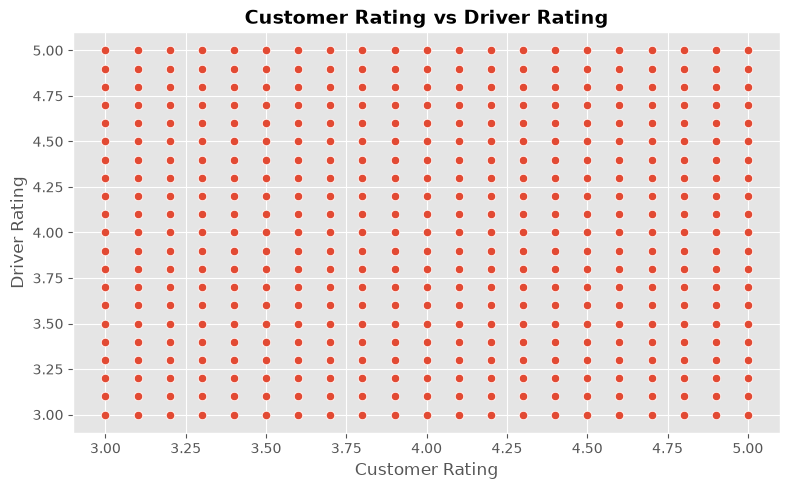

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Customer Rating",
    y="Driver Ratings"
)

plt.title("Customer Rating vs Driver Rating", fontsize=14, fontweight="bold")
plt.xlabel("Customer Rating")
plt.ylabel("Driver Rating")

plt.tight_layout()
plt.show()

Business Insight

Customer and driver ratings generally move together, reflecting overall ride quality.

Q13. What is the customer cancellation rate?

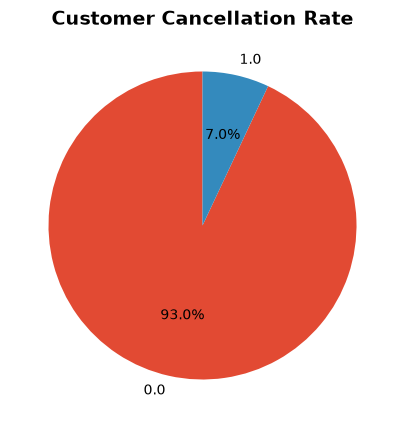

In [29]:
customer_cancel = df["Cancelled Rides by Customer"].value_counts()

plt.figure(figsize=(6,5))

plt.pie(
    customer_cancel,
    labels=customer_cancel.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Cancellation Rate", fontsize=14, fontweight="bold")

plt.show()

Business Insight

Customer cancellations directly affect completed bookings and overall revenue.

Q14. What is the driver cancellation rate?

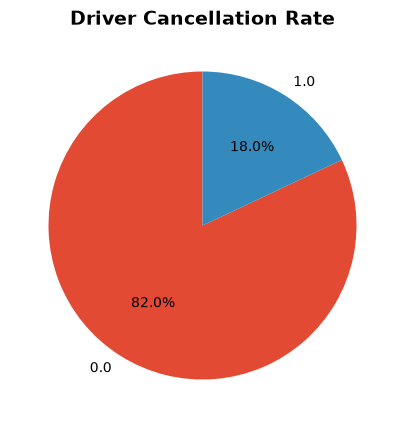

In [30]:
driver_cancel = df["Cancelled Rides by Driver"].value_counts()

plt.figure(figsize=(6,5))

plt.pie(
    driver_cancel,
    labels=driver_cancel.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Driver Cancellation Rate", fontsize=14, fontweight="bold")

plt.show()

Business Insight

Driver cancellations reduce service reliability and impact customer trust.

Q15. What are the top cancellation reasons?

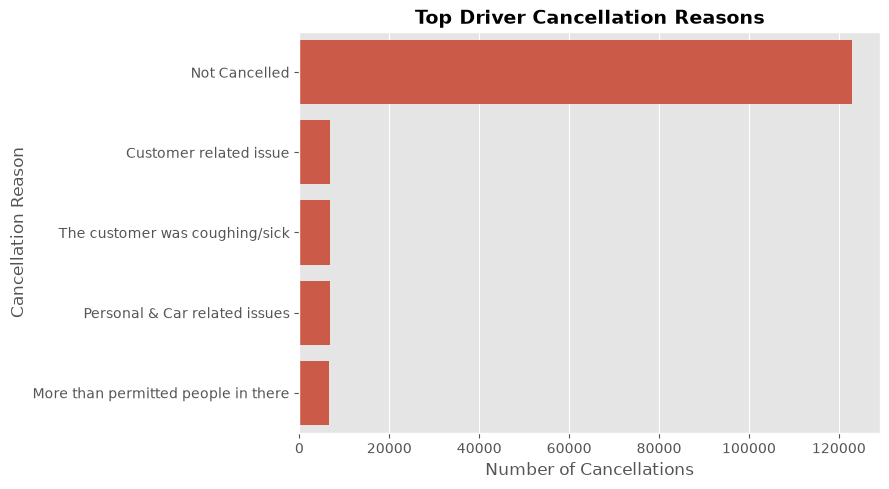

In [31]:
cancel_reason = df["Driver Cancellation Reason"].value_counts().head(10)

plt.figure(figsize=(9,5))

sns.barplot(
    x=cancel_reason.values,
    y=cancel_reason.index
)

plt.title("Top Driver Cancellation Reasons", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cancellations")
plt.ylabel("Cancellation Reason")

plt.tight_layout()
plt.show()

Business Insight

Identifying the most common cancellation reasons helps address operational bottlenecks.

Q16. What is the ratio of completed vs cancelled rides?

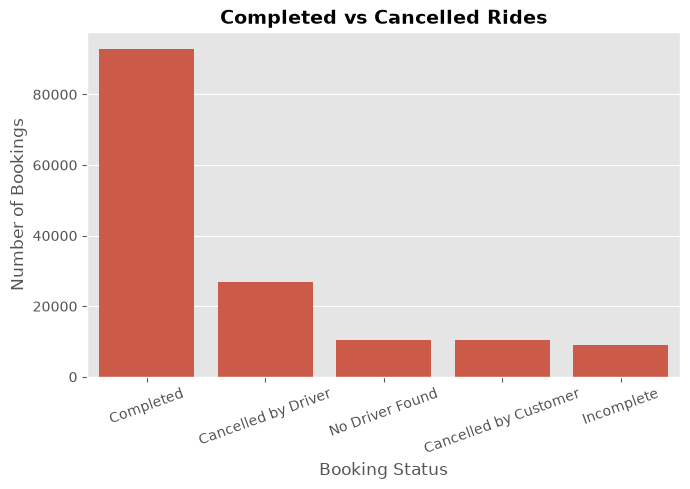

In [32]:
status = df["Booking Status"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=status.index,
    y=status.values
)

plt.title("Completed vs Cancelled Rides", fontsize=14, fontweight="bold")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Business Insight

A higher number of completed rides indicates efficient operations, while cancellations highlight areas for service improvement.

Q17. Which vehicle type has the highest average ride distance?

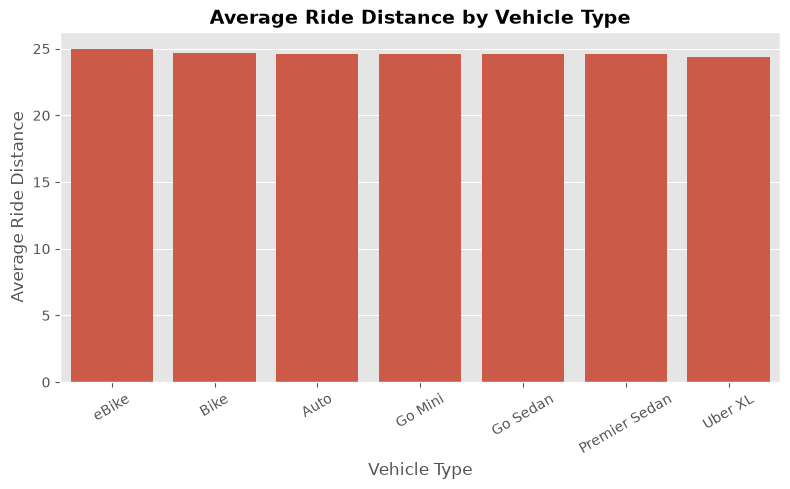

In [33]:
distance = df.groupby("Vehicle Type")["Ride Distance"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=distance.index,
    y=distance.values
)

plt.title("Average Ride Distance by Vehicle Type", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Ride Distance")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Business Insight

Some vehicle categories are preferred for longer trips, while others are mainly used for short-distance travel.

Q18. How does revenue change over time?

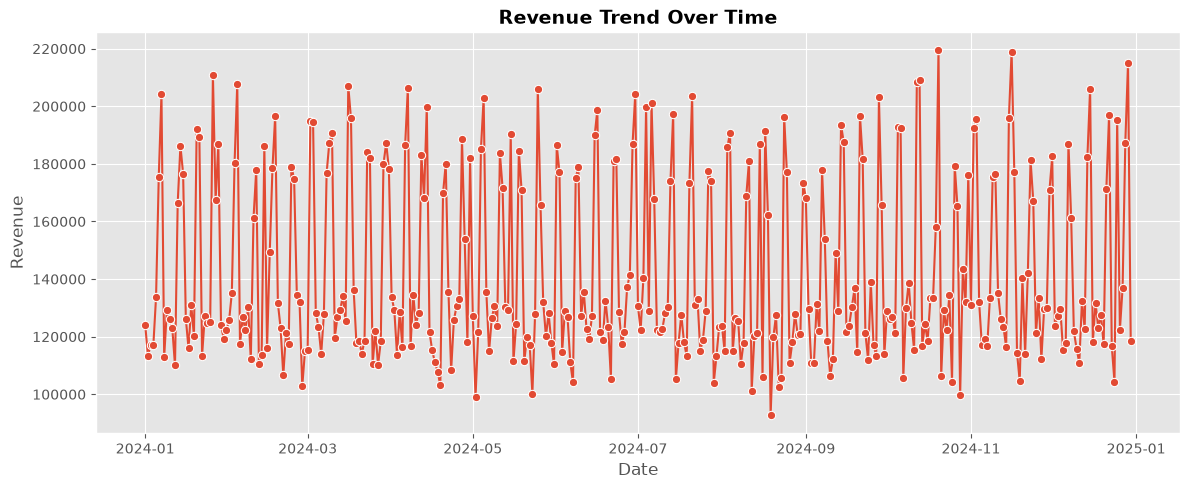

In [34]:
revenue = df.groupby("Date")["Booking Value"].sum()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=revenue.index,
    y=revenue.values,
    marker="o"
)

plt.title("Revenue Trend Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

Business Insight

Revenue fluctuates over time due to changes in customer demand and booking volume.

Q19. Which payment method is used the most?

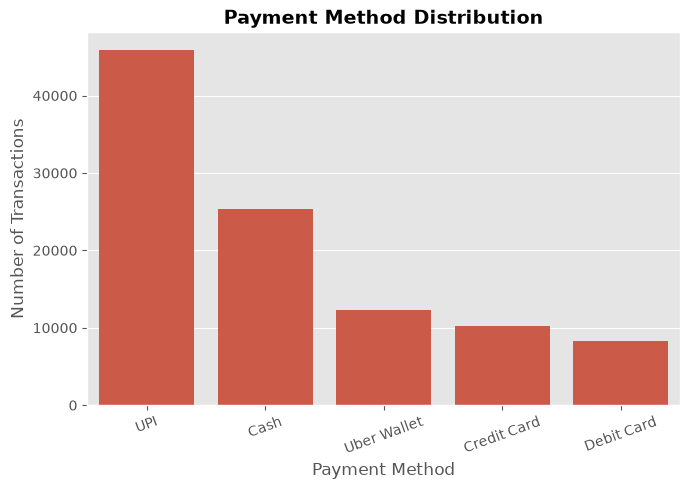

In [35]:
payment = df["Payment Method"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Payment Method Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Business Insight

The most frequently used payment method reflects customer payment preferences.

Q20. What are the key business KPIs?

In [36]:
total_bookings = len(df)

completed = (df["Booking Status"]=="Completed").sum()

total_revenue = df["Booking Value"].sum()

avg_distance = df["Ride Distance"].mean()

avg_rating = df["Customer Rating"].mean()

print("Total Bookings :", total_bookings)
print("Completed Rides :", completed)
print("Total Revenue :", round(total_revenue,2))
print("Average Ride Distance :", round(avg_distance,2))
print("Average Customer Rating :", round(avg_rating,2))

Total Bookings : 150000
Completed Rides : 93000
Total Revenue : 51846183.0
Average Ride Distance : 24.64
Average Customer Rating : 4.4


Business Insight

These KPIs provide a quick overview of operational performance, customer experience, and business revenue.